In [1]:
import tarfile
import os
from glob import glob

# Path to the directory containing all ParlaMint tar.gz files
archive_dir = "/home/tom/data/parlamint/raw/"  # change to your folder
output_dir = "/home/tom/data/parlamint/raw/parlamint"     # where you want to extract them

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Find all .tar.gz files in the archive directory
archives = sorted(glob(os.path.join(archive_dir, "*.tgz")))

print(f"Found {len(archives)} archives.")

# Extract each archive to a subdirectory
for archive in archives:
    country_code = os.path.basename(archive).replace(".tgz", "")
    extract_path = os.path.join(output_dir, country_code)
    os.makedirs(extract_path, exist_ok=True)

    print(f"Extracting {archive} to {extract_path} ...")
    with tarfile.open(archive, "r:gz") as tar:
        tar.extractall(path=extract_path)

print("✅ All archives extracted.")


✅ All archives extracted.


In [6]:
import os
from glob import glob

# Base directory for the TEI English annotated files
tei_base_dir = "/home/tom/data/parlamint/raw/parlamint/ParlaMint-GB-en.ana/ParlaMint-GB-en.TEI.ana"

# Find all 4-digit year subdirectories
year_dirs = [
    os.path.join(tei_base_dir, d) for d in os.listdir(tei_base_dir)
    if os.path.isdir(os.path.join(tei_base_dir, d)) and d.isdigit() and len(d) == 4
]

# Collect all .xml files within each year directory
tei_files = []
for year_dir in sorted(year_dirs):
    files = glob(os.path.join(year_dir, "*.xml"))
    tei_files.extend(files)

print(f"Found {len(tei_files)} XML files across {len(year_dirs)} year-folders.")

Found 2209 XML files across 8 year-folders.


In [3]:
import os
import xml.etree.ElementTree as ET
from collections import defaultdict, Counter
from glob import glob
import re
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

In [39]:
def extract_date(root):
    ns = {'tei': 'http://www.tei-c.org/ns/1.0'}
    date_elem = root.find(".//tei:teiHeader//tei:sourceDesc//tei:bibl//tei:date", ns)
    return date_elem.attrib['when'] if date_elem is not None and 'when' in date_elem.attrib else None


ns = {'tei': 'http://www.tei-c.org/ns/1.0'}

# Stats by YYYY-MM
monthly_counts = Counter()
monthly_lengths = defaultdict(list)

def extract_text(elem):
    return " ".join(elem.itertext()).strip()

for file in tei_files:
    print(file)
    tree = ET.parse(file)
    root = tree.getroot()

    # Extract date from <tei:teiHeader>/<tei:fileDesc>/<tei:sourceDesc>/<tei:bibl>/<tei:date>
    date_str = extract_date(root)
    print(date_str)
    if not date_str:
        print(f"⚠️ Date not found in file: {file}")
        continue

    date = datetime.strptime(date_str, "%Y-%m-%d")
    year_month = date.strftime("%Y-%m")

    # Get all utterances
    utterances = root.findall(".//tei:u", ns)
    print(len(utterances))
    for u in utterances:
        text = extract_text(u)
        word_count = len(text.split())
        monthly_counts[year_month] += 1
        monthly_lengths[year_month].append(word_count)

print("✅ Monthly speech counts and lengths extracted.")


2022-02-25
176
21
93
79
88
83
427
983
47
583
89
253
50
541
61
2339
902
3
1454
61
859
1369
26
885
47
334
653
504
845
69
313
426
302
86
209
105
212
261
269
135
222
91
140
40
110
25
20
89
20
205
168
54
139
99
139
67
154
145
145
109
243
98
148
146
142
91
161
104
25
90
159
36
92
80
282
864
507
71
265
662
159
10
310
59
805
1254
919
1389
33
323
96
866
23
1134
1043
56
816
1011
100
368
456
408
554
236
91
588
249
344
114
29
7
275
101
69
47
183
73
62
98
72
65
162
107
231
89
172
99
2126
1855
73
809
413
116
266
157
364
73
275
193
113
280
72
27
31
31
31
39
36
36
40
36
33
41
32
33
32
34
13
13
13
10
13
13
13
13
10
13
13
13
13
13
13
13
13
13
1151
1144
✅ Monthly speech counts and lengths extracted.


In [40]:
monthly_counts

Counter({'2018-03': 13631,
         '2019-03': 13420,
         '2022-03': 13303,
         '2020-09': 12084,
         '2017-11': 11870,
         '2019-10': 11701,
         '2019-01': 11531,
         '2015-06': 11478,
         '2015-11': 11402,
         '2017-03': 11309,
         '2018-06': 11289,
         '2020-06': 11245,
         '2016-11': 11088,
         '2016-03': 11076,
         '2020-11': 10981,
         '2019-02': 10773,
         '2018-11': 10528,
         '2021-11': 10366,
         '2022-01': 10277,
         '2015-01': 10180,
         '2017-01': 10118,
         '2016-02': 10117,
         '2018-01': 10001,
         '2020-07': 9982,
         '2022-06': 9794,
         '2016-01': 9663,
         '2017-12': 9653,
         '2018-07': 9647,
         '2019-07': 9587,
         '2018-05': 9558,
         '2020-10': 9509,
         '2017-10': 9427,
         '2022-02': 9220,
         '2017-02': 9200,
         '2020-03': 9184,
         '2015-03': 9181,
         '2018-10': 9104,
         '2015-

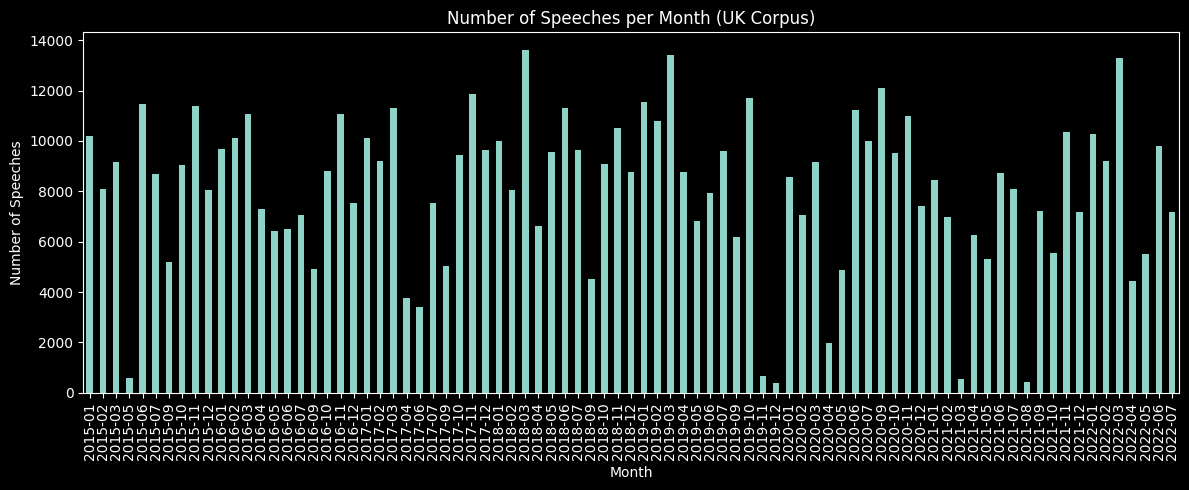

In [41]:
# Convert counts to pandas Series for plotting
monthly_counts_series = pd.Series(monthly_counts).sort_index()

plt.figure(figsize=(12, 5))
monthly_counts_series.plot(kind='bar')
plt.title("Number of Speeches per Month (UK Corpus)")
plt.xlabel("Month")
plt.ylabel("Number of Speeches")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [42]:
# Sum total words per month
monthly_word_counts = {month: sum(lengths) for month, lengths in monthly_lengths.items()}

# Convert to pandas Series for plotting
monthly_words_series = pd.Series(monthly_word_counts).sort_index()

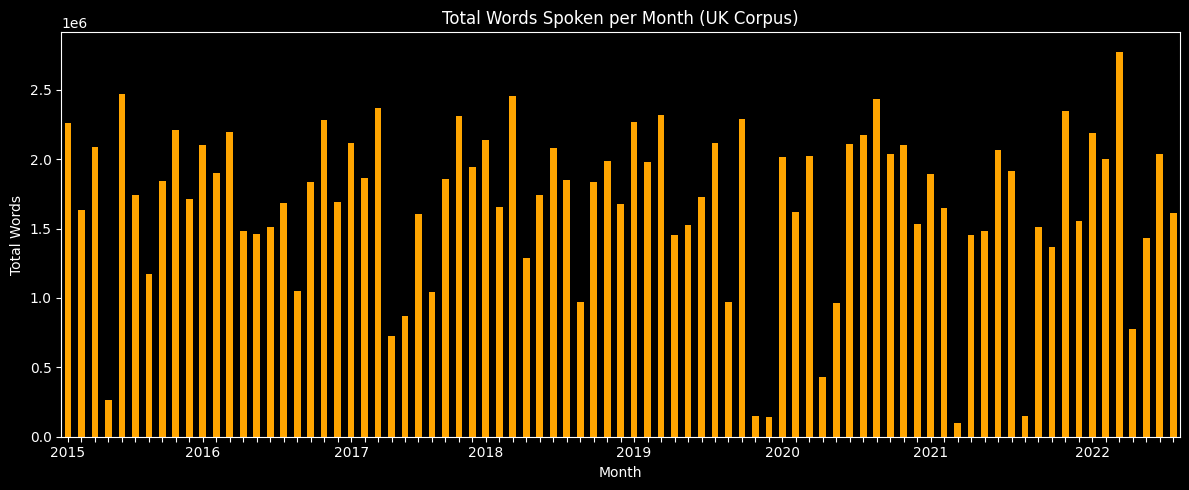

In [44]:
# Extract all months as sorted strings
months = monthly_words_series.index.tolist()
years_seen = set()
tick_labels = []

for m in months:
    year = m[:4]
    if year not in years_seen:
        tick_labels.append(year)
        years_seen.add(year)
    else:
        tick_labels.append("")

plt.figure(figsize=(12, 5))
monthly_words_series.plot(kind='bar', color='orange')

plt.title("Total Words Spoken per Month (UK Corpus)")
plt.xlabel("Month")
plt.ylabel("Total Words")
plt.xticks(ticks=range(len(months)), labels=tick_labels, rotation=0)
plt.tight_layout()
plt.show()


In [9]:
utterances = root.findall(".//{*}u")
print(f"Found {len(utterances)} utterances.")

Found 0 utterances.


In [16]:
# TEI namespace handling
ns = {
    'tei': 'http://www.tei-c.org/ns/1.0'
}

# Find all utterance (<u>) elements
utterances = root.findall(".//tei:u", ns)
print(f"Found {len(utterances)} utterances.")

# Extract the first one
first_u = utterances[5]

# Get the speaker (if annotated)
speaker_id = first_u.attrib.get("who", "Unknown")

# Get the full speech text (joined from <seg>, <p>, <s>, etc.)
def extract_text(elem):
    return " ".join(elem.itertext()).strip()

speech_text = extract_text(first_u)

# Display using Markdown formatting for readability
display(Markdown(f"**Speaker ID**: `{speaker_id}`\n\n**Speech Text**:\n\n{speech_text}"))


**Speaker ID**: `#TheresaMay`

**Speech Text**:

We 
 are 
 doing 
                      
 a 
 great 
 deal 
                      
 of 
 work 
 with 
 the 
 French 
 authorities 
                      
 in 
 relation 
                      
 to 
 the 
 situation 
 at 
 Calais 
 . 
                   
                   
                      
 The 
                      
 hon. 
 Gentleman 
                      
 mentions 
 fingerprinting 
 , 
 and 
 it 
 is 
 important 
 that 
 those 
 who 
 are 
 coming 
 to 
 Calais 
 and 
 trying 
 to 
 get 
 across 
 to 
 the 
                      
 United 
 Kingdom 
                      
 should 
 be 
 fingerprinted 
 when 
 they 
 first 
 enter 
 the 
                      
 European 
 Union 
                      
 . 
                   
                   
                      
 In 
 most 
 cases 
 , 
 they 
 are 
 coming 
 in 
 through 
 Italy 
 .

In [9]:
import os
from glob import glob
import xml.etree.ElementTree as ET
from datetime import datetime
import pandas as pd
from tqdm import tqdm

ns = {'tei': 'http://www.tei-c.org/ns/1.0'}


def extract_date(root):
    ns = {'tei': 'http://www.tei-c.org/ns/1.0'}

    # 1. Primary path
    date_elem = root.find(".//tei:teiHeader//tei:sourceDesc//tei:bibl//tei:date", ns)
    if date_elem is not None and 'when' in date_elem.attrib:
        return date_elem.attrib['when']

    # 2. Fallback with namespace
    date_elem = root.find(".//tei:teiHeader//tei:profileDesc//tei:settingDesc//tei:setting//tei:date", ns)
    if date_elem is not None and 'when' in date_elem.attrib:
        return date_elem.attrib['when']

    # 3. Fallback with wildcard namespace
    date_elem = root.find(".//{*}teiHeader//{*}profileDesc//{*}settingDesc//{*}setting//{*}date")
    if date_elem is not None and 'when' in date_elem.attrib:
        return date_elem.attrib['when']

    return None

def extract_text(elem):
    return " ".join(elem.itertext()).strip()

# Base directory containing all ParlaMint-* country folders
base_dir = "/home/tom/data/parlamint/raw/parlamint"
output = []

# Loop through all countries
country_dirs = [d for d in os.listdir(base_dir) if d.startswith("ParlaMint-") and os.path.isdir(os.path.join(base_dir, d))]

for country_folder in tqdm(sorted(country_dirs)):
    country_code = country_folder.split("-")[1]  # e.g., ParlaMint-GB → GB

    # Look for a subdirectory ending in '.TEI.ana'
    subdirs = [os.path.join(base_dir, country_folder, d)
           for d in os.listdir(os.path.join(base_dir, country_folder))
           if d.endswith(".TEI.ana") and os.path.isdir(os.path.join(base_dir, country_folder, d))]

    if not subdirs:
        print(f"❌ Skipping {country_code} — no .TEI.ana folder found.")
        continue

    ana_dir = subdirs[0]  # Assume one such folder per country

    # Look in all year subfolders
    year_dirs = [os.path.join(ana_dir, y) for y in os.listdir(ana_dir)
                 if os.path.isdir(os.path.join(ana_dir, y)) and y.isdigit() and len(y) == 4]

    for year_dir in year_dirs:
        tei_files = glob(os.path.join(year_dir, "*.xml"))
        for file in tei_files:
            try:
                tree = ET.parse(file)
                root = tree.getroot()
                date_str = extract_date(root)
                if not date_str:
                    print('No date found for ' + str(file))
                    continue
                date = datetime.strptime(date_str, "%Y-%m-%d").date()

                utterances = root.findall(".//tei:u", ns)
                total_words = 0
                for u in utterances:
                    text = extract_text(u)
                    total_words += len(text.split())

                output.append({
                    "country": country_code,
                    "date": date,
                    "words": total_words
                })
            except Exception as e:
                print(f"⚠️ Error in file {file}: {e}")
                continue


KeyboardInterrupt: 

In [109]:
output = []
country_folder = country_dirs[22]
country_code = country_folder.split("-")[1]  # e.g., ParlaMint-GB → GB

# Look for a subdirectory ending in '.TEI.ana'
subdirs = [os.path.join(base_dir, country_folder, d)
       for d in os.listdir(os.path.join(base_dir, country_folder))
       if d.endswith(".TEI.ana") and os.path.isdir(os.path.join(base_dir, country_folder, d))]

if not subdirs:
    print(f"❌ Skipping {country_code} — no .TEI.ana folder found.")


ana_dir = subdirs[0]  # Assume one such folder per country

# Look in all year subfolders
year_dirs = [os.path.join(ana_dir, y) for y in os.listdir(ana_dir)
             if os.path.isdir(os.path.join(ana_dir, y)) and y.isdigit() and len(y) == 4]

for year_dir in year_dirs:
    tei_files = glob(os.path.join(year_dir, "*.xml"))
    for file in tei_files:
        try:
            tree = ET.parse(file)
            root = tree.getroot()
            date_str = extract_date(root)
            if not date_str:
                print('No date found for ' + str(file))
                continue
            date = datetime.strptime(date_str, "%Y-%m-%d").date()
            print(date)
            utterances = root.findall(".//tei:u", ns)
            print(len(utterances))
            total_words = 0
            for u in utterances:
                text = extract_text(u)
                total_words += len(text.split())

            output.append({
                "country": country_code,
                "date": date,
                "words": total_words
            })
        except Exception as e:
            print(f"⚠️ Error in file {file}: {e}")
            continue

KeyboardInterrupt: 

In [2]:
df = pd.DataFrame(output)
df = df.sort_values(by=["country", "date"]).reset_index(drop=True)
print(df.head())

# Save to CSV
df.to_csv("/home/tom/projects/corpora/data/processed/parlamint_word_counts_by_day_v2.csv", index=False)

  country        date  words
0      AT  1996-01-15  13938
1      AT  1996-01-15    818
2      AT  1996-01-15    263
3      AT  1996-01-30  64667
4      AT  1996-01-31  64149


In [1]:
print("OK")

OK


In [3]:
# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Group by country and month, summing word counts
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby(["country", "month"])["words"].sum().reset_index()

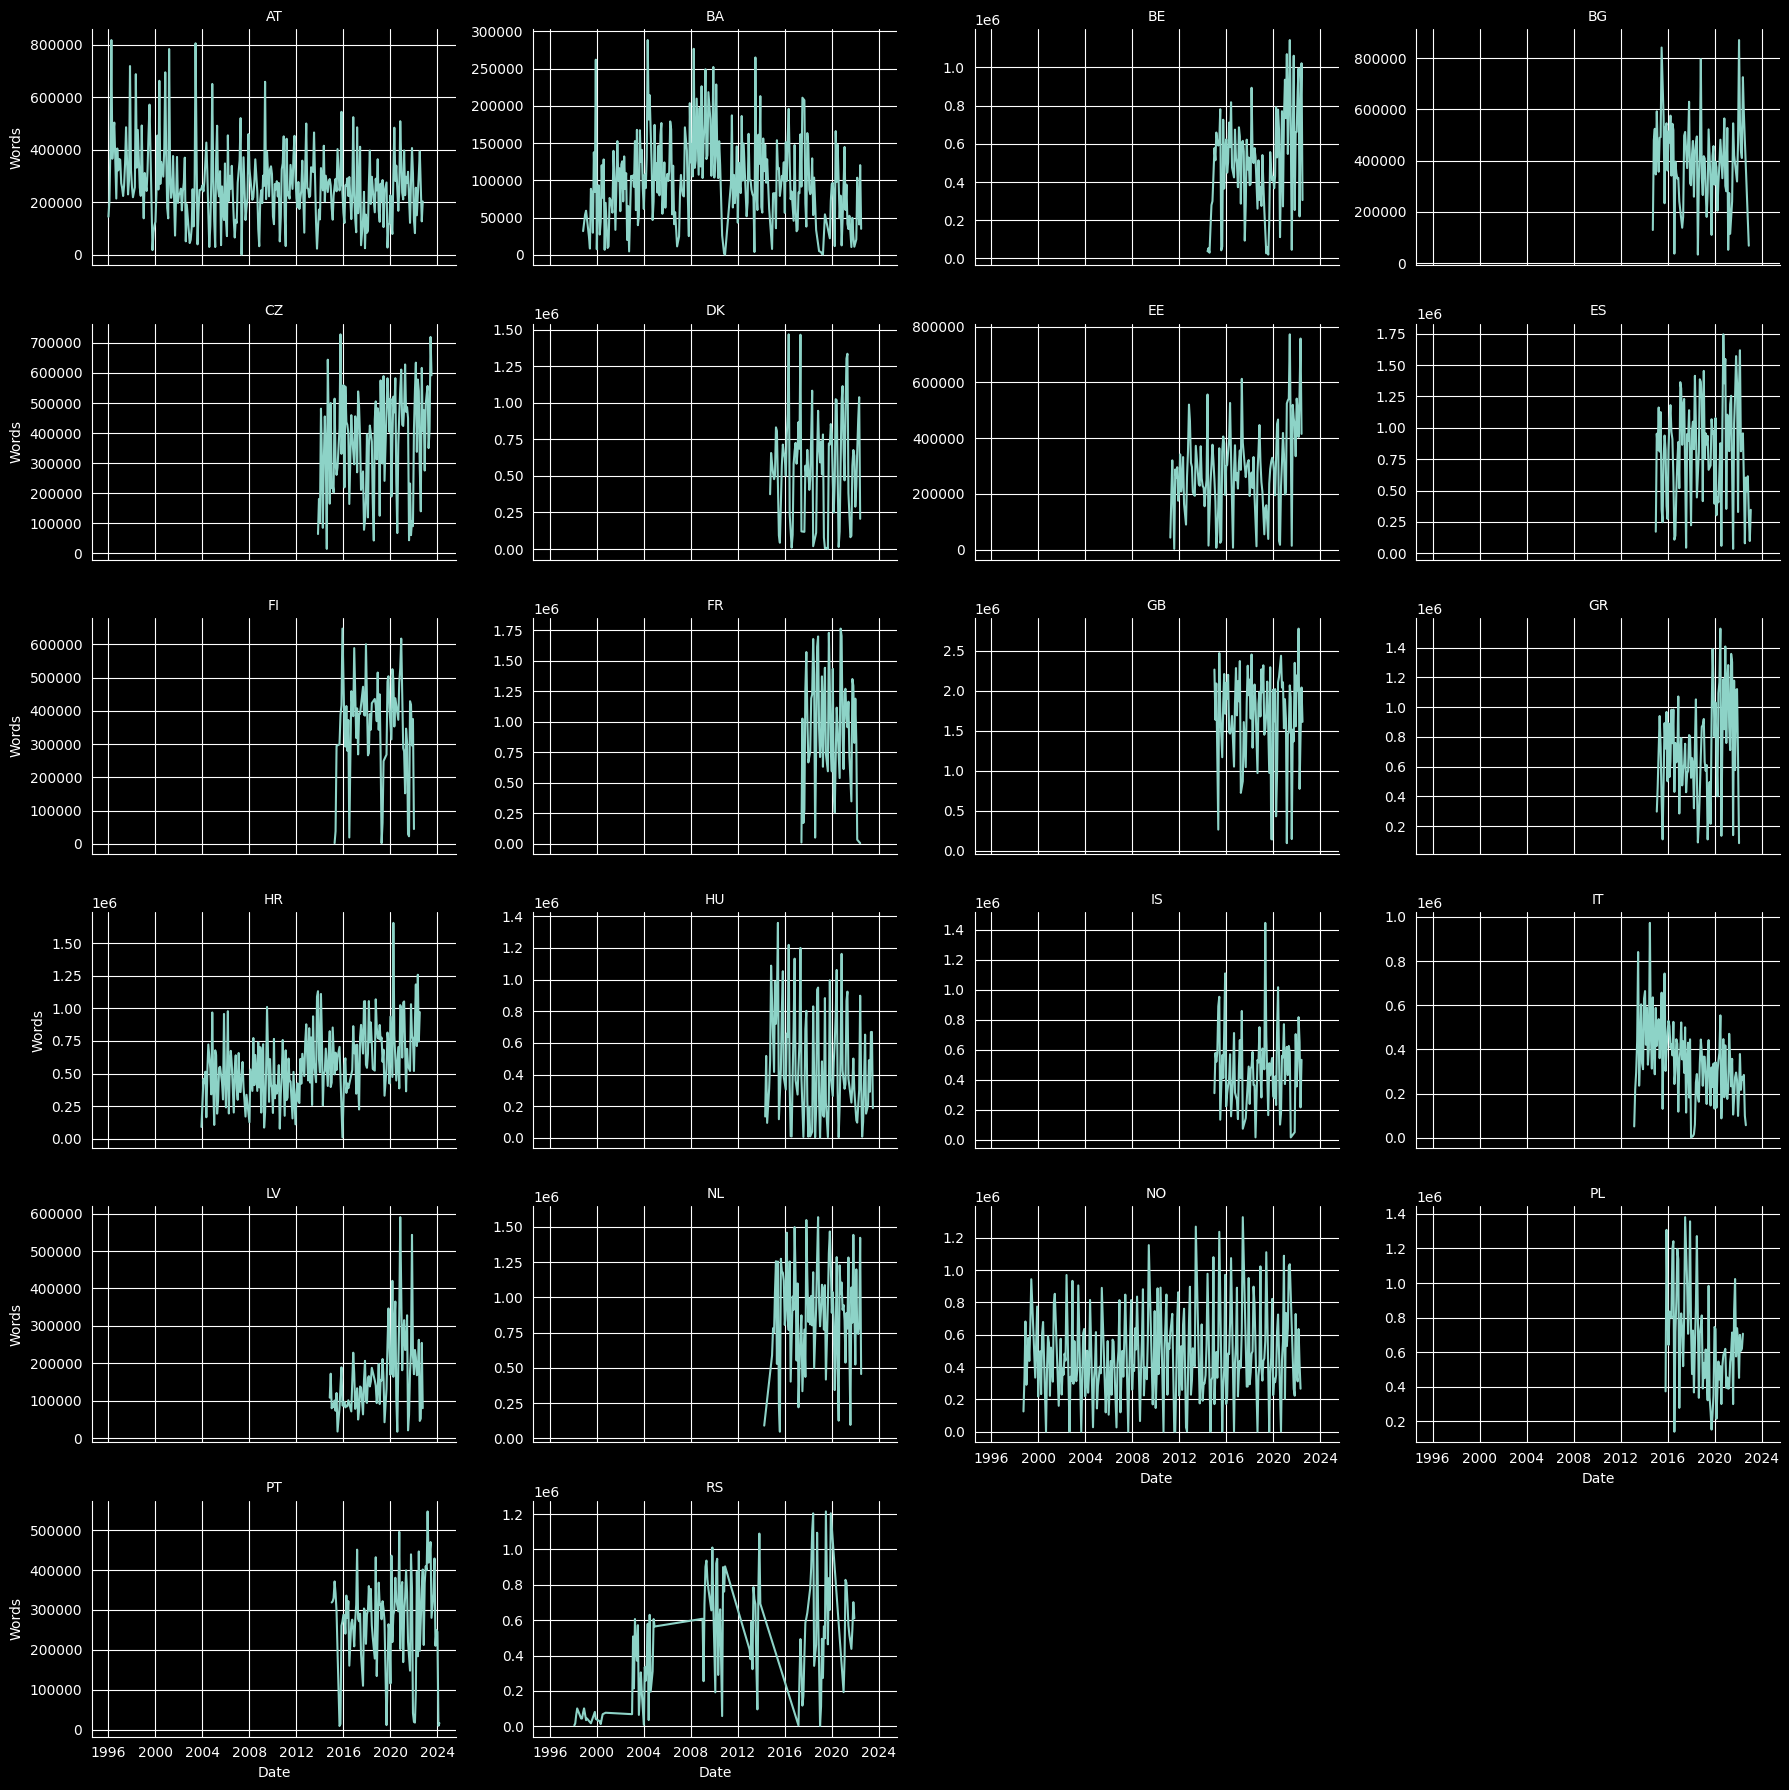

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure 'month' is datetime
monthly["month"] = pd.to_datetime(monthly["month"])

# Optionally sort country codes
all_countries = sorted(monthly["country"].unique())

# Plot all countries using FacetGrid
g = sns.relplot(
    data=monthly,
    x="month", y="words", kind="line",
    col="country", col_wrap=4, height=3, aspect=1.5,
    facet_kws=dict(sharey=False)
)

g.set_titles("{col_name}")
g.set_axis_labels("Date", "Words")
plt.tight_layout()


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Ensure correct format
monthly["month"] = pd.to_datetime(monthly["month"])
monthly["month_ordinal"] = monthly["month"].map(lambda d: d.toordinal())

# Use fewer countries if needed
top_countries = monthly["country"].value_counts().nlargest(15).index
monthly_ridge = monthly[monthly["country"].isin(top_countries)].copy()

# Sort country order
country_order = sorted(top_countries)
monthly_ridge["country"] = pd.Categorical(monthly_ridge["country"], categories=country_order, ordered=True)

# Set up plot
plt.figure(figsize=(12, 10))
colors = sns.cubehelix_palette(len(country_order), rot=-.25, light=.7)

# Draw one KDE per country, offset vertically
for i, country in enumerate(country_order):
    subset = monthly_ridge[monthly_ridge["country"] == country]
    if subset.shape[0] < 3:
        continue

    x = subset["month_ordinal"]
    weights = subset["words"]
    kde = sns.kdeplot(
        x=x,
        weights=weights,
        bw_adjust=0.3,
        fill=True,
        alpha=1,
        linewidth=1.5,
        color=colors[i]
    )

    # Shift curve up by i
    for collection in kde.collections:
        collection.set_offsets([(p[0], p[1] + i) for p in collection.get_offsets()])

    # Label
    plt.text(x.min(), i + 0.1, country, ha='left', va='center', fontsize=9, color=colors[i])

# Final tweaks
plt.yticks([])
plt.xlabel("Year")
plt.title("Monthly Speech Volume per Country (Ridge Plot Style)")

# Set readable date ticks
xticks = np.linspace(monthly["month_ordinal"].min(), monthly["month_ordinal"].max(), 8).astype(int)
xtick_labels = [datetime.fromordinal(t).strftime('%Y') for t in xticks]
plt.xticks(xticks, xtick_labels)

plt.tight_layout()
plt.savefig("/home/tom/projects/corpora/data/processed/ridge_plot_fixed.png", dpi=300)
from IPython.display import Image, display
display(Image(filename="ridge_plot_fixed.png"))


NameError: name 'monthly' is not defined

In [16]:
import os
from glob import glob
import xml.etree.ElementTree as ET
from datetime import datetime
import pandas as pd
from tqdm import tqdm

base_dir = "/home/tom/data/parlamint/raw/parlamint"
country_dirs = [d for d in os.listdir(base_dir) if d.startswith("ParlaMint-") and os.path.isdir(os.path.join(base_dir, d))]

# Add these to your output list
meta_output = []

for country_folder in tqdm(sorted(country_dirs)):
    country_code = country_folder.split("-")[1]

    subdirs = [os.path.join(base_dir, country_folder, d)
               for d in os.listdir(os.path.join(base_dir, country_folder))
               if d.endswith(".TEI.ana") and os.path.isdir(os.path.join(base_dir, country_folder, d))]

    if not subdirs:
        print(f"❌ Skipping {country_code} — no .TEI.ana folder found.")
        continue

    ana_dir = subdirs[0]
    # Path to listPerson.xml (usually named like ParlaMint-XX-listPerson.xml)
    person_file = glob(os.path.join(ana_dir, "*listPerson.xml"))
    speaker_ids = set()
    speaker_info = {}

    if person_file:
        try:
                tree = ET.parse(person_file[0])
                root = tree.getroot()
                persons = root.findall(".//tei:person", ns)
                for p in persons:
                    pid = p.attrib.get("{http://www.w3.org/XML/1998/namespace}id")
                    if pid:
                        speaker_ids.add(pid)
                        speaker_info[pid] = {
                            "name": extract_text(p.find(".//tei:persName", ns)),
                            "sex": p.findtext(".//tei:sex", default=None, namespaces=ns),
                            "birth": p.findtext(".//tei:birth", default=None, namespaces=ns)
                            # You can expand this with affiliations, party, etc.
                        }
        except Exception as e:
                print(f"⚠️ Error parsing listPerson for {country_code}: {e}")
    else:
        print(f"❌ No listPerson file for {country_code}")

    year_dirs = [os.path.join(ana_dir, y) for y in os.listdir(ana_dir)
                 if os.path.isdir(os.path.join(ana_dir, y)) and y.isdigit() and len(y) == 4]

    for year_dir in year_dirs:
        tei_files = glob(os.path.join(year_dir, "*.xml"))
        for file in tei_files:
            try:
                tree = ET.parse(file)
                root = tree.getroot()
                date_str = extract_date(root)
                if not date_str:
                    continue
                date = datetime.strptime(date_str, "%Y-%m-%d").date()

                # Get location and chamber (if available)
                location_elem = root.find(".//tei:setting//tei:name[@type='city']", ns)
                chamber_elem = root.find(".//tei:setting//tei:name[@type='chamber']", ns) or \
                               root.find(".//tei:setting//tei:name[@type='house']", ns)

                location = location_elem.text.strip() if location_elem is not None else None
                chamber = chamber_elem.text.strip() if chamber_elem is not None else None

                # Analyze speeches
                utterances = root.findall(".//tei:u", ns)
                num_speeches = len(utterances)
                num_with_speaker = 0
                num_with_known_speaker = 0
                total_words = 0

                for u in utterances:
                    text = extract_text(u)
                    total_words += len(text.split())
                    speaker_id = u.attrib.get("who", "").lstrip("#")

                    if speaker_id:
                        num_with_speaker += 1
                        if speaker_id in speaker_ids:
                            num_with_known_speaker += 1
                            speaker_meta = speaker_info.get(speaker_id)

                meta_output.append({
                    "country": country_code,
                    "date": date,
                    "location": location,
                    "chamber": chamber,
                    "total_words": total_words,
                    "num_speeches": num_speeches,
                    "with_speaker": num_with_speaker,
                    "with_known_speaker": num_with_known_speaker
                })

            except Exception as e:
                print(f"⚠️ Error in file {file}: {e}")
                continue


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.DataFrame(meta_output)
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby(["country", "month"])["total_words"].sum().reset_index()


def generate_country_report(country_code, df, monthly, output_dir="country_reports"):
    os.makedirs(output_dir, exist_ok=True)

    country_df = df[df["country"] == country_code]
    country_monthly = monthly[monthly["country"] == country_code]

    # Stats
    total_words = country_df["total_words"].sum()
    total_speeches = country_df["num_speeches"].sum()
    with_speaker = country_df["with_speaker"].sum()
    with_known = country_df["with_known_speaker"].sum()
    first_date = country_df["date"].min().date()
    last_date = country_df["date"].max().date()

    # Plot
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=country_monthly, x="month", y="total_words")
    plt.title(f"{country_code} – Words per Month")
    plt.ylabel("Words")
    plt.xlabel("Month")
    plt.tight_layout()

    # Save plot
    plot_path = os.path.join(output_dir, f"{country_code}_words_plot.png")
    plt.savefig(plot_path, dpi=200)
    plt.close()

    # Print or save summary
    report = f"""📋 Report for {country_code}
———————————————
Total words: {total_words:,}
Total speeches: {total_speeches:,}
Speeches with speaker ID: {with_speaker:,}
Speeches with known speaker metadata: {with_known:,}
Date range: {first_date} → {last_date}
Plot saved to: {plot_path}
"""
    print(report)
    return report


In [32]:
df.to_csv('../data/processed/parlamint_daily.csv')

In [19]:
all_reports = []

for country_code in df["country"].unique():
    report = generate_country_report(country_code, df, monthly)
    all_reports.append(report)

📋 Report for PT
———————————————
Total words: 28,212,296
Total speeches: 248,577
Speeches with speaker ID: 248,577
Speeches with known speaker metadata: 248,577
Date range: 2015-01-07 → 2024-03-13
Plot saved to: country_reports/PT_words_plot.png

📋 Report for RS
———————————————
Total words: 51,701,864
Total speeches: 139,970
Speeches with speaker ID: 139,885
Speeches with known speaker metadata: 139,885
Date range: 1998-02-19 → 2021-12-29
Plot saved to: country_reports/RS_words_plot.png



In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# === CONFIG ===
plot_dir = "../data/country_reports_scaled"
output_html = "ParlaMint_Report.html"

# === Prepare per-country stats ===
def extract_country_stats(country_code, df, monthly):
    country_df = df[df["country"] == country_code]
    country_monthly = monthly[monthly["country"] == country_code]

    if country_df.empty or country_monthly.empty:
        return None

    # Generate scaled plot
    img_name = f"{country_code}_words_plot.png"
    img_path = os.path.join(plot_dir, img_name)

    plt.figure(figsize=(8, 3))
    sns.lineplot(data=country_monthly, x="month", y="total_words")
    plt.title(f"{country_code} – Words per Month")
    plt.xlabel("Month")
    plt.ylabel("Words")
    plt.tight_layout()
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(img_path, dpi=100, bbox_inches="tight")
    plt.close()

    return {
        "country": country_code,
        "total_words": int(country_df["total_words"].sum()),
        "total_speeches": int(country_df["num_speeches"].sum()),
        "with_speaker": int(country_df["with_speaker"].sum()),
        "with_known": int(country_df["with_known_speaker"].sum()),
        "first_date": country_df["date"].min().date(),
        "last_date": country_df["date"].max().date(),
        "image": img_path
    }

# === Build HTML ===
def generate_html_report(stats_list, output_path=output_html):
    html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>ParlaMint Report</title>
    <style>
        body { font-family: sans-serif; margin: 40px; }
        h2 { margin-top: 2em; border-bottom: 1px solid #ccc; padding-bottom: 0.2em; }
        img { max-width: 100%; height: auto; margin-top: 10px; }
        .stat { margin: 5px 0; }
    </style>
</head>
<body>
    <h1>📊 ParlaMint Country-Level Report</h1>
"""

    for stats in stats_list:
        rel_path = os.path.relpath(stats["image"], os.path.dirname(output_path))
        html += f"""
    <h2>{stats['country']}</h2>
    <div class="stat"><strong>Total words:</strong> {stats['total_words']:,}</div>
    <div class="stat"><strong>Total speeches:</strong> {stats['total_speeches']:,}</div>
    <div class="stat"><strong>Speeches with speaker ID:</strong> {stats['with_speaker']:,}</div>
    <div class="stat"><strong>With known speaker metadata:</strong> {stats['with_known']:,}</div>
    <div class="stat"><strong>Date range:</strong> {stats['first_date']} → {stats['last_date']}</div>
    <img src="{rel_path}" alt="{stats['country']} plot"/>
"""

    html += "\n</body></html>"

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html)

    print(f"✅ HTML report saved to: {output_path}")

# === Main execution ===
all_stats = []
for country in sorted(df["country"].unique()):
    stats = extract_country_stats(country, df, monthly)
    if stats:
        all_stats.append(stats)

generate_html_report(all_stats)


✅ HTML report saved to: ParlaMint_Report.html


In [25]:
markdown_blocks = []

for country_code in sorted(df["country"].unique()):
    block = generate_country_report_md(country_code, df, monthly)
    markdown_blocks.append(block)

# Write to file
with open("../data/country_reports/ParlaMint_Report.md", "w", encoding="utf-8") as f:
    f.write("# 📊 ParlaMint Country-Level Report\n\n")
    f.write("\n---\n".join(markdown_blocks))

print("✅ Markdown report generated at: country_reports/ParlaMint_Report.md")


✅ Markdown report generated at: country_reports/ParlaMint_Report.md


In [27]:
import markdown2
from weasyprint import HTML

with open("/data/country_reports/ParlaMint_Report.md", "r", encoding="utf-8") as f:
    html = markdown2.markdown(f.read())

HTML(string=html, base_url=".").write_pdf("/home/tom/projects/corpora/notebooks/country_reports/ParlaMint_Report.pdf")


In [30]:
from PIL import Image
import os
from glob import glob

image_dir = "../data/country_reports"
output_dir = "../data/country_reports_scaled"
os.makedirs(output_dir, exist_ok=True)

# Resize all *_words_plot.png
for path in glob(os.path.join(image_dir, "*_words_plot.png")):
    img = Image.open(path)
    img_resized = img.resize((100, 40), Image.LANCZOS)

    out_path = os.path.join(output_dir, os.path.basename(path))
    img_resized.save(out_path)

print("✅ All plots resized and saved to:", output_dir)


✅ All plots resized and saved to: country_reports_scaled


In [29]:
fig.savefig("country_reports_scaled/TEST_small_AT_words_plot.png", dpi=80, bbox_inches="tight")

NameError: name 'fig' is not defined